# Insurence_casestudy

**Note:**
- In this experiment, we will perform several operations on a CSV file using the NumPy, Pandas, Matplotlib, and Seaborn libraries.
- Our main focus will be on key operations that are commonly used in these libraries.
- The following operations will be conducted on the CSV file:
  - Importing the necessary libraries.
  - Loading the dataset into the experiment.
  - Understanding the data in the file.
  - Performing data cleaning and visualization operations.
  - Preparing the data for further processes in the Data Science Life Cycle.

**Experment Link** --> https://colab.research.google.com/drive/10_RC98FNXb7HMAPfOkl2F9LjY2Yz0bAs?usp=sharing

**Data set Link** --> https://drive.google.com/file/d/1Js0IiFk-ZhjOzpfIIRDkz79KM8TaZCUk/view?usp=sharing

In [197]:
# Importing the required libraries.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [198]:
# Loading the data_set.
df = pd.read_csv("/content/insurance (1).csv")

In [199]:
# Understanding the data_set.
df.head()

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region,charges
0,18.0,male,23.21,0.0,no,29087.54313,17.0,715428.0,4720920.992,0.0,55784970.05,southeast,1121.8739
1,18.0,male,30.14,0.0,no,39053.67437,7.0,699157.0,4329831.676,0.0,13700885.19,southeast,1131.5066
2,18.0,male,33.33,0.0,no,39023.62759,19.0,702341.0,6884860.774,0.0,73523107.27,southeast,1135.9407
3,18.0,male,33.66,0.0,no,28185.39332,11.0,700250.0,4274773.550,0.0,75819679.60,southeast,1136.3994
4,18.0,male,34.10,0.0,no,14697.85941,16.0,711584.0,3787293.921,0.0,23012320.01,southeast,1137.0110


In [200]:
df.shape

(1338, 13)

In [201]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 13 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   age                              1329 non-null   float64
 1   sex                              1338 non-null   object 
 2   bmi                              1335 non-null   float64
 3   children                         1333 non-null   float64
 4   smoker                           1338 non-null   object 
 5   Claim_Amount                     1324 non-null   float64
 6   past_consultations               1332 non-null   float64
 7   num_of_steps                     1335 non-null   float64
 8   Hospital_expenditure             1334 non-null   float64
 9   NUmber_of_past_hospitalizations  1336 non-null   float64
 10  Anual_Salary                     1332 non-null   float64
 11  region                           1338 non-null   object 
 12  charges             

- Observing the data set for how many types of data are contained in the CSV_file.

- By this, we understand the dataset's composition and the different data types present in the file.

In [202]:
df.describe()

,age,bmi,children,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,charges
count,1329.000000,1335.000000,1333.000000,1324.000000,1332.000000,1.335000e+03,1.334000e+03,1336.000000,1.332000e+03,1338.000000
mean,39.310008,30.665112,1.090773,33361.327180,15.216216,9.100047e+05,1.584179e+07,1.060629,3.696849e+08,13270.422265
std,14.034818,6.101690,1.201856,15617.288337,7.467723,9.188612e+04,2.669305e+07,0.533583,5.668843e+08,12110.011237
min,18.000000,15.960000,0.000000,1920.136268,1.000000,6.954300e+05,2.945253e+04,0.000000,2.747072e+06,1121.873900
25%,27.000000,26.302500,0.000000,20768.860390,9.000000,8.471995e+05,4.077633e+06,1.000000,7.701932e+07,4740.287150
50%,39.000000,30.400000,1.000000,33700.310675,15.000000,9.143000e+05,7.490337e+06,1.000000,1.419361e+08,9382.033000
75%,51.000000,34.687500,2.000000,45052.331957,20.000000,9.716840e+05,1.084082e+07,1.000000,3.243499e+08,16639.912515
max,64.000000,53.130000,5.000000,77277.988480,40.000000,1.107872e+06,2.616317e+08,3.000000,4.117197e+09,63770.428010


-  We are now going to perform some data cleaning operations on the file.

In [203]:
columns_df = df.columns

In [204]:
# checking for null values
df.isnull().sum()

,0
age,9
sex,0
bmi,3
children,5
smoker,0
Claim_Amount,14
past_consultations,6
num_of_steps,3
Hospital_expenditure,4
NUmber_of_past_hospitalizations,2


In [205]:
df.isnull().sum().sum()

np.int64(52)

- Since these null values are not significant, we will use the 'dropna()' function to remove them.

In [206]:
df.dropna(inplace=True)

In [207]:
# checking for duplicate values
df.duplicated().sum()

np.int64(0)

- We are identifying the outliers in the dataset to reduce inconsistency.

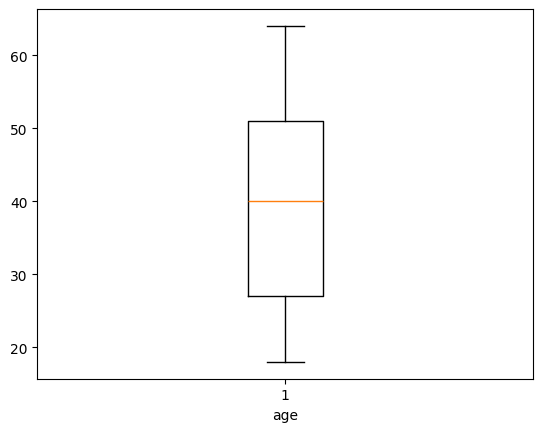

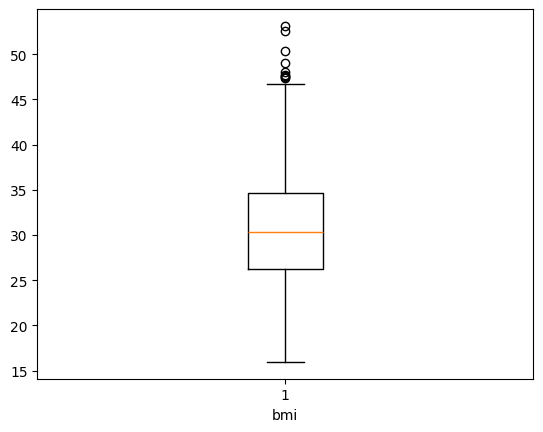

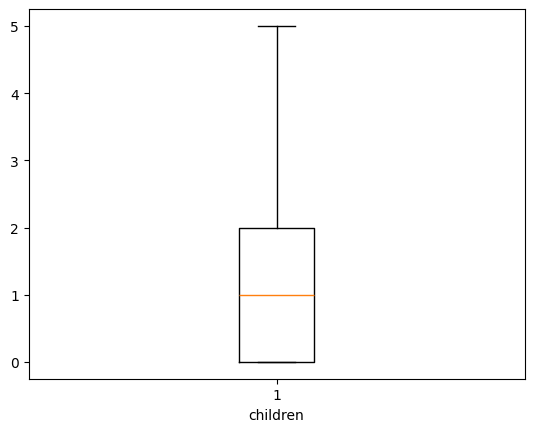

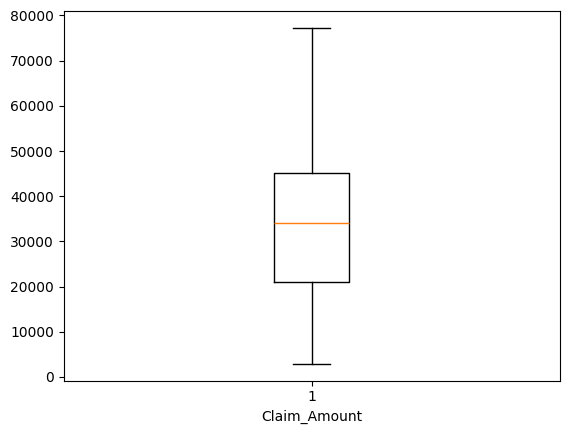

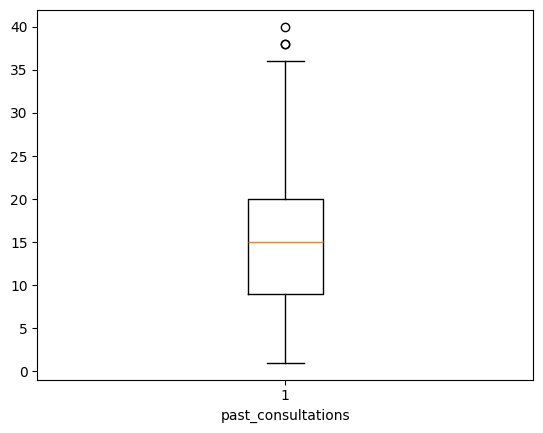

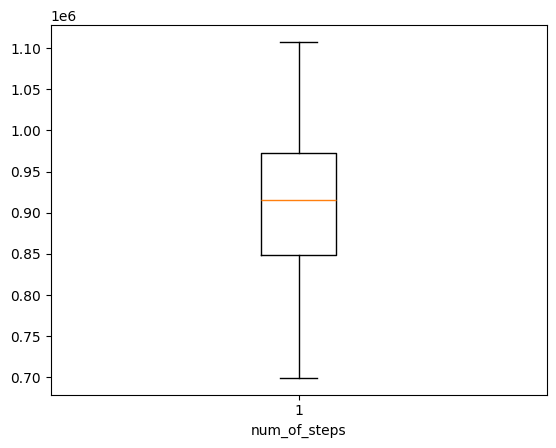

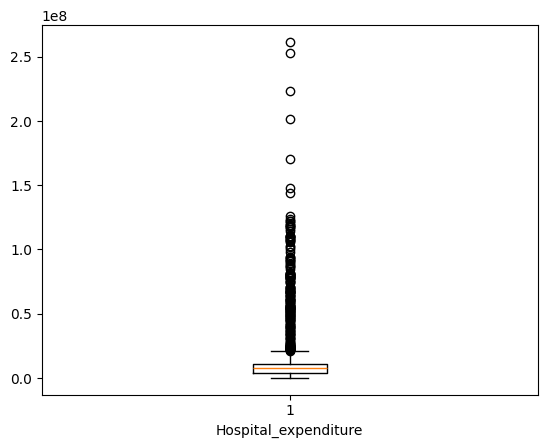

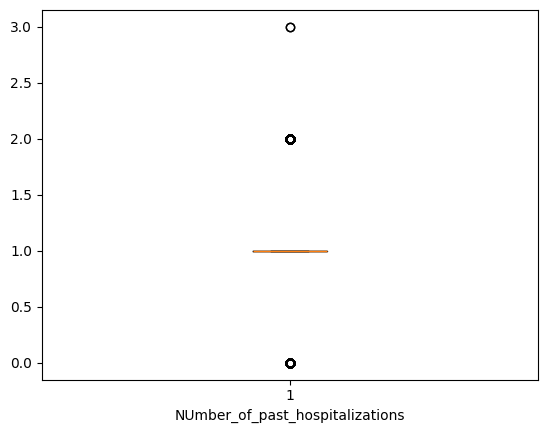

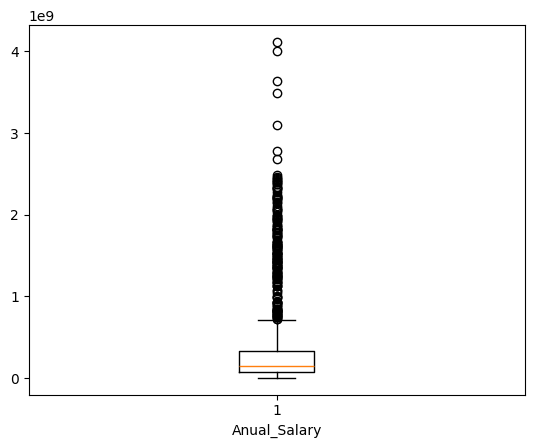

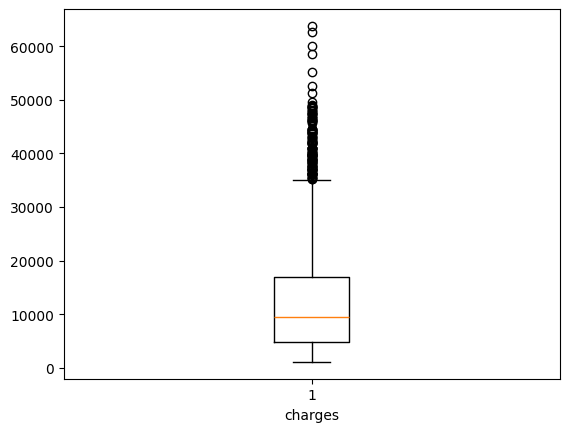

In [208]:
# Checking for outliers in the numeric columns.
for i in df.columns:
  if df[i].dtype == 'int64' or df[i].dtype == 'float64':
    plt.boxplot(df[i])
    plt.xlabel(i)
    plt.show()

In [209]:
# Caluculatre the outliers quantity in the numeric columns.
for i in df.columns:
  if df[i].dtype !='object':
    Q1 = df[i].quantile(0.25)
    Q3 = df[i].quantile(0.75)

In [210]:
IQR = Q3 - Q1

In [211]:
UB = Q3 + 1.5*IQR
LB = Q1 - 1.5*IQR

In [212]:
df = df[(df['charges'] >= LB) & (df['charges'] <= UB)]

In [213]:
df.shape

(1162, 13)

1. Checking how many males and females are in the dataset by using the 'Value_counts()' function.

In [214]:
df['sex'].value_counts()

,count
sex,
female,600
male,562


- Visualising the males and females in the pie chart as a percentage.

<Axes: ylabel='count'>

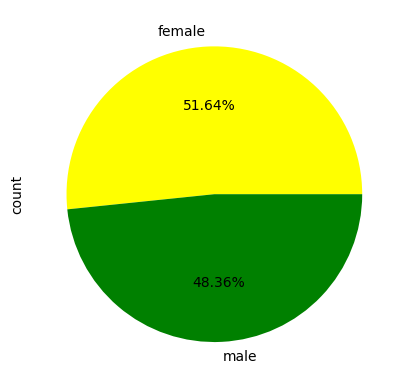

In [215]:
df['sex'].value_counts().plot.pie(autopct='%1.2f%%',colors = ['yellow','green'])

2. Determine the number of males and females in each region of the dataset.

In [216]:
count = df.groupby('region')['sex'].value_counts()

In [217]:
count

region     sex   
northeast  female    149
           male      141
northwest  female    152
           male      143
southeast  female    152
           male      146
southwest  female    147
           male      132
Name: count, dtype: int64

3. Calculate the average annual salaries of individuals in each region.

In [218]:
df.groupby('region')['Anual_Salary'].mean()

,Anual_Salary
region,
northeast,2.264590e+08
northwest,2.206570e+08
southeast,2.071592e+08
southwest,1.876362e+08


4. Investigating how most of the income has been spent on hospitals.

In [219]:
top_5_payers = df.sort_values('Hospital_expenditure',ascending=False).head(5)

In [220]:
top_5_payers.head(1)

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region,charges
1201,19.0,male,34.8,0.0,yes,28937.12615,20.0,1043930.0,51338277.22,2.0,1.284642e+09,southwest,34779.615


5. Comparing the smoker and charges columns to understand how paying charges affects the insurance.

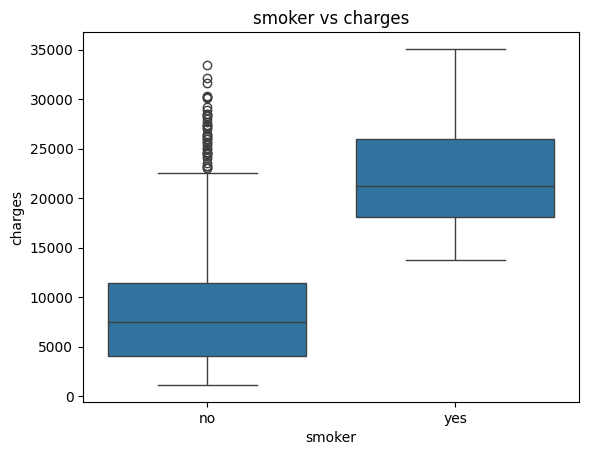

In [221]:
sns.boxplot(x='smoker',y='charges',data=df)
plt.title('smoker vs charges')
plt.show()

- We have only removed the outliers in numeric columns, which is why outliers remain in the object columns.

6. Checking the dataset to determine which age group is most represented.

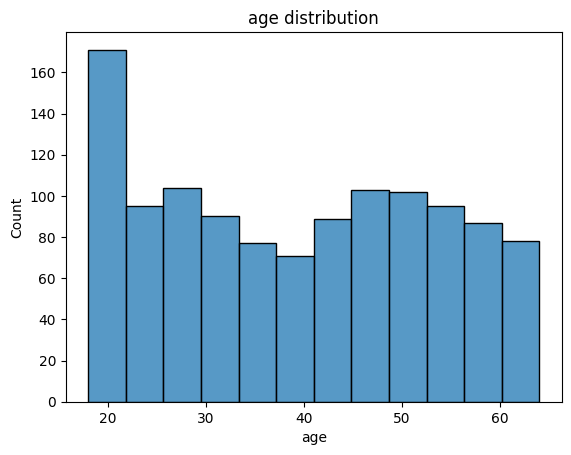

In [222]:
sns.histplot(df['age'])
plt.title('age distribution')
plt.show()

7. Analysing the dataset with a scatter plot of the age and charges columns to determine which age group has the highest charges.

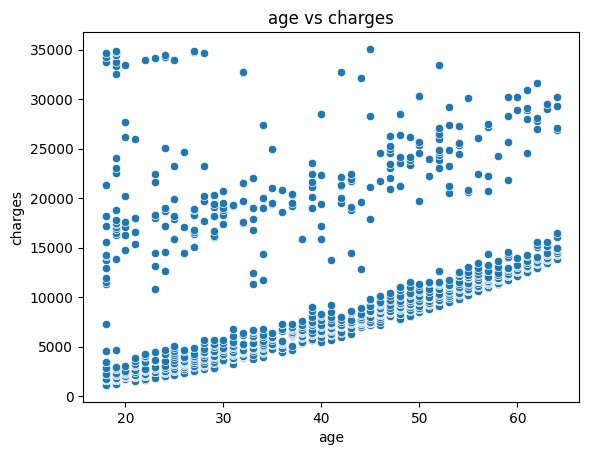

In [223]:
sns.scatterplot(x='age',y='charges',data=df)
plt.title('age vs charges')
plt.show()